# FIAP Tech Challenge — Fase 4
## Modelo LSTM PETR4 (v7.5 - Versão Final Documentada)

Este notebook apresenta a implementação final do modelo de predição de preços para PETR4.SA, unindo o rigor técnico de feature engineering com as ferramentas de rastreamento do MLflow.

### 1. Importação de Bibliotecas e Configuração do Dispositivo
Preparamos o ambiente carregando o PyTorch e configurando o uso de GPU (CUDA) se disponível.

In [80]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import mlflow
import mlflow.pytorch

# Configuração visual e de dispositivo
sns.set_theme(style='whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Executando em: {DEVICE}')

Executando em: cuda


### 2. Definição de Hiperparâmetros
Aqui configuramos os parâmetros do modelo e do processo de treinamento, como o tamanho da janela temporal e taxa de aprendizado.

In [81]:
SYMBOL = 'PETR4.SA'
WINDOW_SIZE = 30    # Dias de histórico usados para prever o dia seguinte
HIDDEN_SIZE = 64    # Neurônios na camada oculta da LSTM
NUM_LAYERS = 2      # Camadas de LSTM empilhadas
BATCH_SIZE = 32     # Tamanho do lote de processamento
NUM_EPOCHS = 150    # Limite máximo de épocas
PATIENCE = 15       # Paciência para o Early Stopping
LEARNING_RATE = 0.001
EXPERIMENT_NAME = 'LSTM_PETR4_Final_Diagnostics'

### 3. Coleta de Dados e Feature Engineering
Baixamos os dados reais via Yahoo Finance e calculamos indicadores técnicos (Médias Móveis, Volatilidade, Momentum) que ajudam o modelo a entender o mercado.

In [82]:
def get_engineered_data():
    import yfinance as yf
    # Coleta de dados históricos
    df = yf.download(SYMBOL, start='2018-01-01', progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    
    data = df.copy()
    # Médias Móveis Simples
    data['SMA_7'] = data['Close'].rolling(7).mean()
    data['SMA_21'] = data['Close'].rolling(21).mean()
    # Retornos e Volatilidade
    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
    data['Volatility_21'] = data['Log_Return'].rolling(21).std()
    # Momentum e Volume Z-Score
    data['Momentum_5'] = data['Close'] - data['Close'].shift(5)
    data['Volume_Z'] = (data['Volume'] - data['Volume'].rolling(21).mean()) / data['Volume'].rolling(21).std()
    
    return data.dropna()

df_feat = get_engineered_data()
PRICE_COLS = ['Close', 'Open', 'High', 'Low', 'SMA_7', 'SMA_21']
STAT_COLS = ['Log_Return', 'Volatility_21', 'Momentum_5', 'Volume_Z']
FEATURES = PRICE_COLS + STAT_COLS

### 4. Normalização e Criação de Janelas
Aplicamos a normalização relativa (âncora no 1º dia da janela) para preços e Z-Score para indicadores. Isso garante que o modelo aprenda padrões, independente do valor nominal da ação.

In [83]:
def create_v6_windows(df, window_size, price_cols, stat_cols):
    # Split para fit do scaler apenas no treino (evita data leakage)
    train_split = int(len(df) * 0.8)
    df_train = df.iloc[:train_split]
    
    scaler_stat = StandardScaler()
    scaler_stat.fit(df_train[stat_cols].values)
    
    X, y, anchors = [], [], []
    data_vals = df[price_cols + stat_cols].values
    closes = df['Close'].values
    p_idx = list(range(len(price_cols)))
    s_idx = list(range(len(price_cols), len(price_cols) + len(stat_cols)))
    
    for i in range(window_size, len(df)):
        window = data_vals[i-window_size : i].copy()
        anchor = closes[i-window_size] # Preço do primeiro dia da janela
        
        # Normaliza preços pela âncora e indicadores pelo scaler global
        window[:, p_idx] = window[:, p_idx] / anchor
        window[:, s_idx] = scaler_stat.transform(window[:, s_idx])
        
        X.append(window)
        y.append(closes[i] / anchor) # Target como ratio da âncora
        anchors.append(anchor)
        
    return np.array(X), np.array(y).reshape(-1, 1), np.array(anchors)

X_raw, y_raw, anchors = create_v6_windows(df_feat, WINDOW_SIZE, PRICE_COLS, STAT_COLS)
split = int(len(X_raw) * 0.8)

# Preparação final dos Tensores e DataLoaders
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_raw[:split]), torch.FloatTensor(y_raw[:split])), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.FloatTensor(X_raw[split:]), torch.FloatTensor(y_raw[split:])), batch_size=BATCH_SIZE)

### 5. Arquitetura do Modelo LSTM
Seguimos o estilo sugerido pelo professor: uma camada LSTM seguida de uma cabeça de saída Linear enxuta.

In [84]:
class LSTMModel(nn.Module):
    def __init__(self, in_sz, hid_sz, layers):
        super().__init__()
        self.lstm = nn.LSTM(in_sz, hid_sz, layers, batch_first=True, dropout=0.2)
        self.head = nn.Sequential(nn.Linear(hid_sz, 1))
        
    def forward(self, x):
        # Retornamos apenas a saída do último passo temporal da LSTM
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

### 6. Lógica de Treinamento e Rastreamento (MLflow)
O loop de treinamento integra o Early Stopping para evitar overfitting e loga todos os parâmetros e métricas no MLflow automaticamente.

In [85]:
def train_model():
    model = LSTMModel(len(FEATURES), HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()
    history = {'train': [], 'val': []}
    best_loss, patience_cnt, best_state = float('inf'), 0, None
    
    mlflow.set_experiment(EXPERIMENT_NAME)
    with mlflow.start_run():
        # Log dos parâmetros no estilo do professor
        mlflow.log_param('intermediate_layers', ['LSTM', 'Linear'])
        mlflow.log_param('input_size', len(FEATURES))
        mlflow.log_param('hidden_size', HIDDEN_SIZE)
        mlflow.log_param('num_layers', NUM_LAYERS)
        
        for epoch in range(NUM_EPOCHS):
            model.train()
            t_losses = []
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(xb.to(DEVICE)), yb.to(DEVICE))
                loss.backward(); optimizer.step()
                t_losses.append(loss.item())
            
            # Avaliação de Validação
            model.eval()
            v_losses = [criterion(model(xv.to(DEVICE)), yv.to(DEVICE)).item() for xv, yv in test_loader]
            
            avg_t, avg_v = np.mean(t_losses), np.mean(v_losses)
            history['train'].append(avg_t); history['val'].append(avg_v)
            mlflow.log_metric('train_mse', avg_t, step=epoch)
            mlflow.log_metric('val_mse', avg_v, step=epoch)
            
            # Lógica de persistência do melhor modelo
            if avg_v < best_loss:
                best_loss, patience_cnt, best_state = avg_v, 0, model.state_dict()
            else:
                patience_cnt += 1
            
            if (epoch+1) % 20 == 0: print(f'Epoch {epoch+1} | T-Loss: {avg_t:.6f} | V-Loss: {avg_v:.6f}')
            if patience_cnt >= PATIENCE:
                print(f'Early Stop na época {epoch}'); break
        
        model.load_state_dict(best_state)
        mlflow.pytorch.log_model(model, 'model')
        return model, history

### 7. Execução e Diagnóstico Final
Rodamos o treinamento e plotamos a curva de aprendizado para validar a convergência e a predição final no conjunto de teste.

Epoch 20 | T-Loss: 0.001136 | V-Loss: 0.000396


2026/05/13 21:23:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Early Stop na época 25


2026/05/13 21:23:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/13 21:23:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/13 21:23:48 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label 

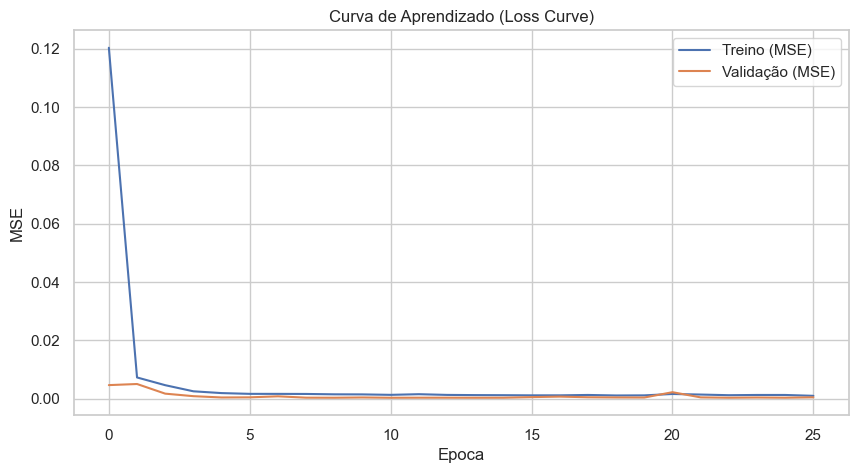

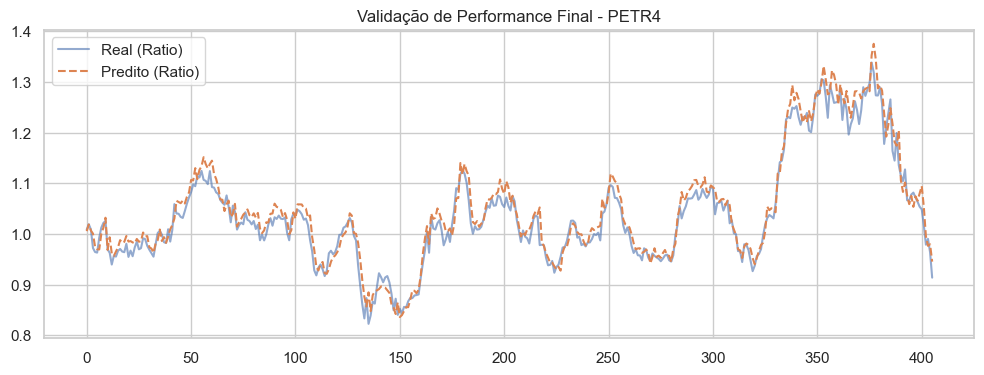

In [86]:
model, history = train_model()

# Gráfico 1: Diagnóstico de Treinamento (Check de Overfitting)
plt.figure(figsize=(10, 5))
plt.plot(history['train'], label='Treino (MSE)')
plt.plot(history['val'], label='Validação (MSE)')
plt.title('Curva de Aprendizado (Loss Curve)')
plt.xlabel('Epoca'); plt.ylabel('MSE')
plt.legend(); plt.show()

# Gráfico 2: Resultado Final (Predição no Teste)
model.eval()
with torch.no_grad():
    preds = model(torch.FloatTensor(X_raw[split:]).to(DEVICE)).cpu().numpy()
    actuals = y_raw[split:]

plt.figure(figsize=(12, 4))
plt.plot(actuals, label='Real (Ratio)', alpha=0.6)
plt.plot(preds, label='Predito (Ratio)', linestyle='--')
plt.title('Validação de Performance Final - PETR4')
plt.legend(); plt.show()